In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [4]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [6]:
df.replace("?", np.nan, inplace=True)

In [7]:
df.drop(['policy_number'], axis=1, inplace=True, errors='ignore')

In [8]:
df.fillna(df.mode().iloc[0], inplace=True)

In [9]:
df['fraud_reported'] = df['fraud_reported'].map({'Y':1,'N':0})

In [10]:
df = pd.get_dummies(df, drop_first=True)

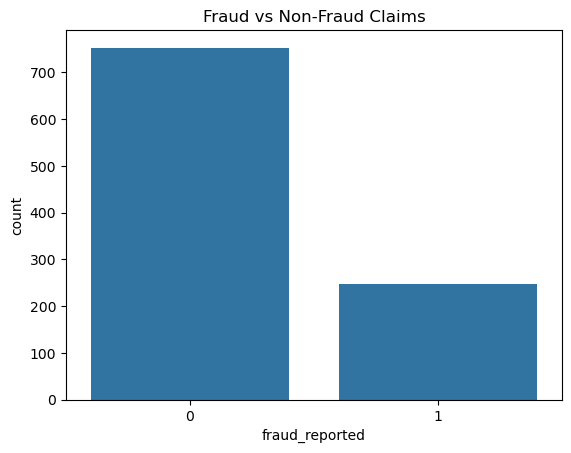

In [11]:
sns.countplot(x='fraud_reported', data=df)

plt.title("Fraud vs Non-Fraud Claims")

plt.show()

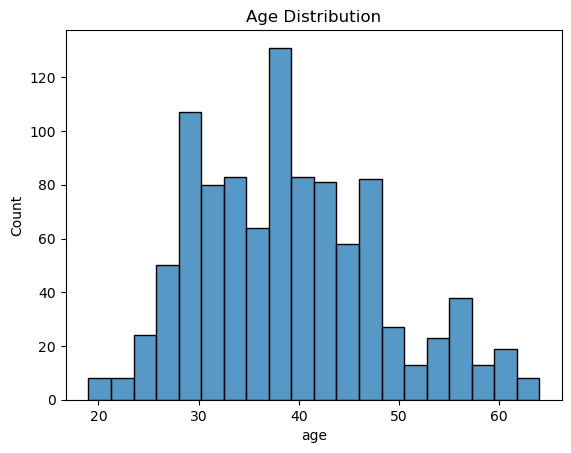

In [12]:
sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")

plt.show()

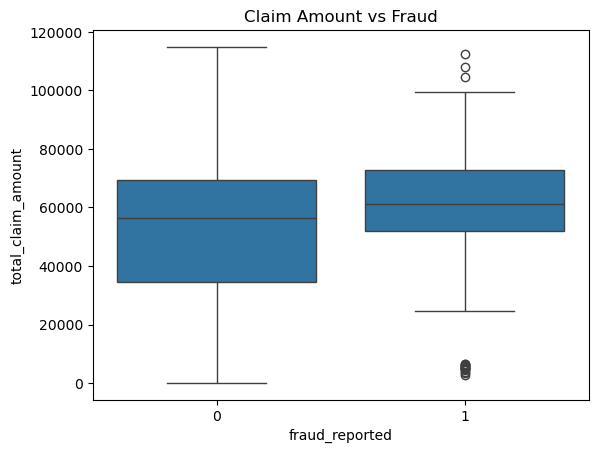

In [12]:
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df)

plt.title("Claim Amount vs Fraud")

plt.show()

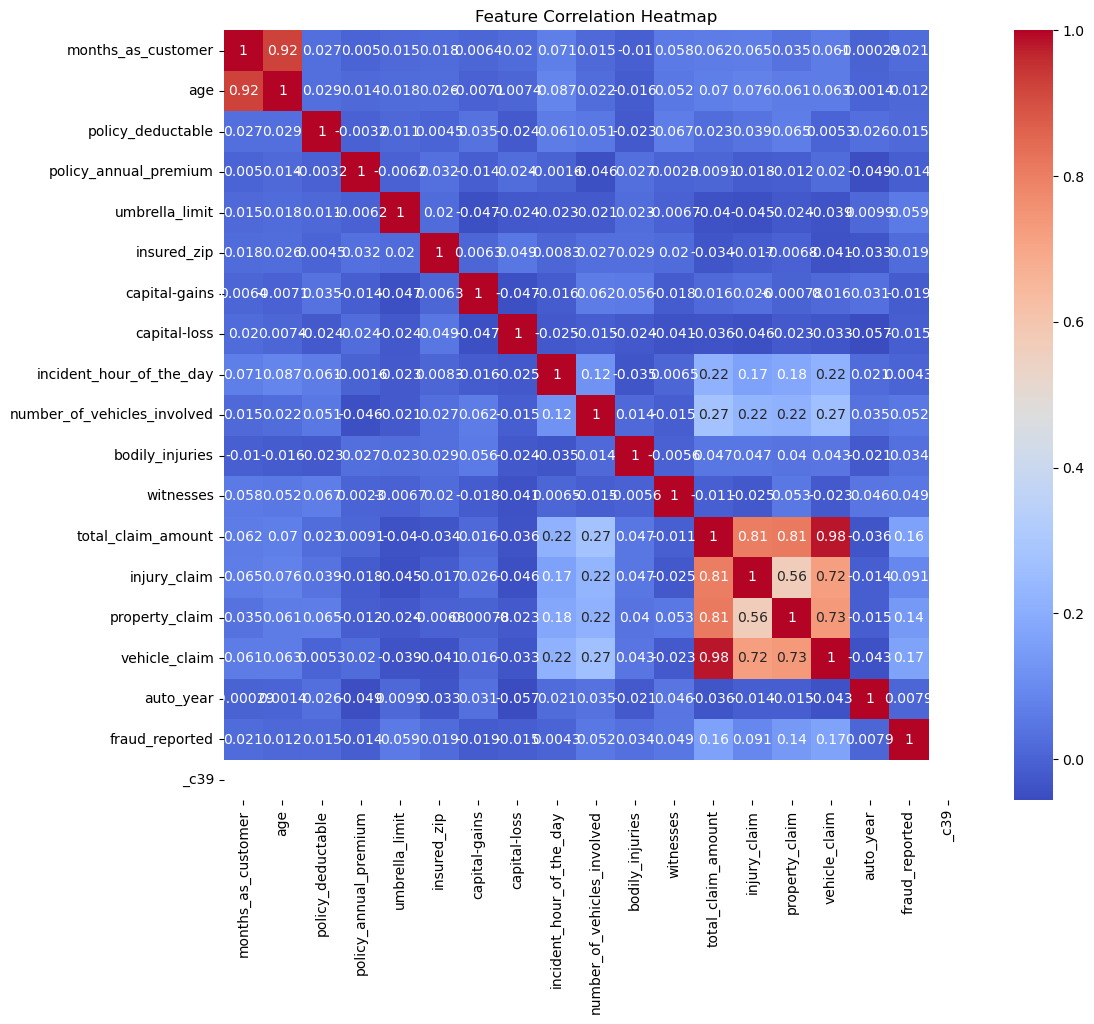

In [13]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,10))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [14]:
X = df.drop('fraud_reported', axis=1)

y = df['fraud_reported']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

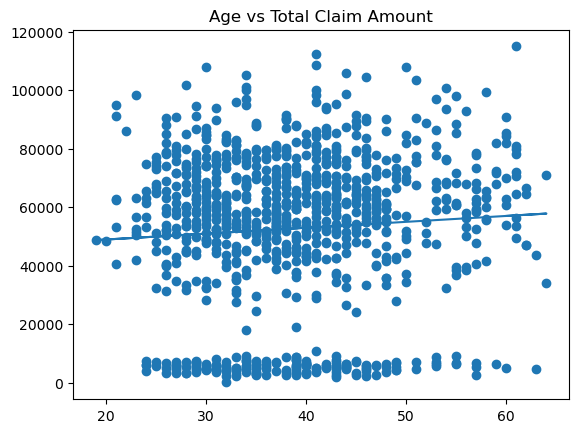

In [16]:
X_reg = df[['age']]

y_reg = df['total_claim_amount']

model = LinearRegression()

model.fit(X_reg, y_reg)

y_pred = model.predict(X_reg)

plt.scatter(X_reg, y_reg)

plt.plot(X_reg, y_pred)

plt.title("Age vs Total Claim Amount")

plt.show()

In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [19]:
X_cluster = df[['age','total_claim_amount']]

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_cluster)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


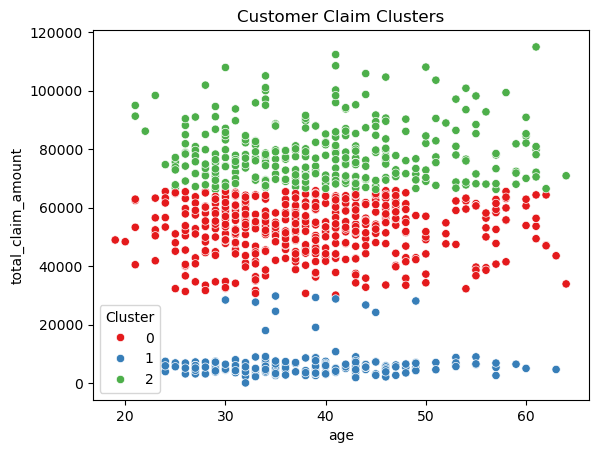

In [20]:
sns.scatterplot(x='age',
                y='total_claim_amount',
                hue='Cluster',
                data=df,
                palette='Set1')

plt.title("Customer Claim Clusters")

plt.show()